In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

cnc = pd.read_csv("../../data/processed/cnc_cleaned.csv")
print(cnc.shape)
print(cnc.head())

(10000, 12)
  type  air_temp_k  process_temp_k  rotational_speed_rpm  torque_nm  \
0    M       298.1           308.6                  1551       42.8   
1    L       298.2           308.7                  1408       46.3   
2    L       298.1           308.5                  1498       49.4   
3    L       298.2           308.6                  1433       39.5   
4    L       298.2           308.7                  1408       40.0   

   tool_wear_min  machine_failure  twf  hdf  pwf  osf  rnf  
0              0                0    0    0    0    0    0  
1              3                0    0    0    0    0    0  
2              5                0    0    0    0    0    0  
3              7                0    0    0    0    0    0  
4              9                0    0    0    0    0    0  


In [2]:
failure_counts = cnc["machine_failure"].value_counts().reset_index()
failure_counts.columns = ["status", "count"]
failure_counts["status"] = failure_counts["status"].map({0: "Normal", 1: "Failure"})

fig = px.bar(failure_counts, x="status", y="count",
             color="status",
             color_discrete_map={"Normal": "#2563eb", "Failure": "#ef4444"},
             title="CNC — Failure vs Normal Distribution",
             text="count")
fig.update_layout(showlegend=False)
fig.show()

print("Failure rate:", round(cnc["machine_failure"].mean() * 100, 2), "%")

Failure rate: 3.39 %


In [3]:
sensors = ["air_temp_k", "process_temp_k", "rotational_speed_rpm", 
           "torque_nm", "tool_wear_min"]

for sensor in sensors:
    fig = px.box(cnc, x="machine_failure", y=sensor,
                 color="machine_failure",
                 color_discrete_map={0: "#2563eb", 1: "#ef4444"},
                 title=f"CNC — {sensor} by Failure Status",
                 labels={"machine_failure": "Failure"})
    fig.show()

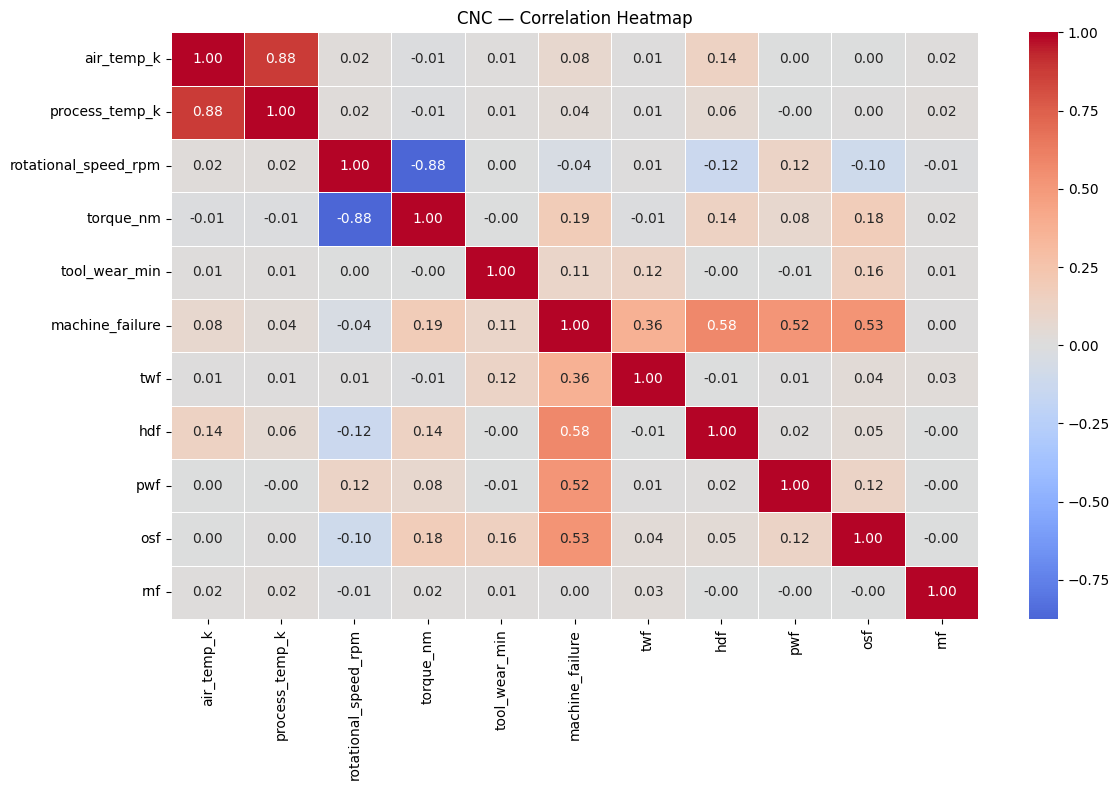

In [4]:
cnc_numeric = cnc.select_dtypes(include=np.number)

plt.figure(figsize=(12, 8))
sns.heatmap(cnc_numeric.corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0,
            linewidths=0.5)
plt.title("CNC — Correlation Heatmap")
plt.tight_layout()
plt.savefig("../../reports/figures/cnc_correlation_heatmap.png", dpi=150)
plt.show()

In [10]:
fig = px.histogram(cnc, x="tool_wear_min", color="machine_failure",
                   color_discrete_map={0: "#2563eb", 1: "#ef4444"},
                   barmode="overlay",
                   title="CNC — Tool Wear Distribution by Failure",
                   labels={"machine_failure": "Failure", "tool_wear_min": "Tool Wear (min)"},
                   opacity=0.7,
                   nbins=50)
fig.show()

In [11]:
type_failure = cnc.groupby("type")["machine_failure"].mean().reset_index()
type_failure.columns = ["type", "failure_rate"]
type_failure["failure_rate"] = (type_failure["failure_rate"] * 100).round(2)

fig = px.bar(type_failure, x="type", y="failure_rate",
             title="CNC — Failure Rate by Machine Type (%)",
             text="failure_rate",
             color="type")
fig.update_traces(texttemplate="%{text}%")
fig.show()

In [7]:
# Temperature difference between process and air
cnc["temp_diff"] = cnc["process_temp_k"] - cnc["air_temp_k"]

# Power proxy
cnc["power_proxy"] = cnc["torque_nm"] * cnc["rotational_speed_rpm"]

print("New columns added:", ["temp_diff", "power_proxy"])
print(cnc[["temp_diff", "power_proxy"]].describe())

New columns added: ['temp_diff', 'power_proxy']
          temp_diff   power_proxy
count  10000.000000  10000.000000
mean      10.000630  59967.147040
std        1.001094  10193.093881
min        7.600000  10966.800000
25%        9.300000  53105.400000
50%        9.800000  59883.900000
75%       11.000000  66873.750000
max       12.100000  99980.400000


In [8]:
import os
os.makedirs("../../reports/figures", exist_ok=True)

# Save updated CSV with engineered features
cnc.to_csv("../../data/processed/cnc_cleaned.csv", index=False)
print("Saved updated CNC CSV with new features.")

Saved updated CNC CSV with new features.


In [9]:
import sys
print(sys.executable)

/Library/Frameworks/Python.framework/Versions/3.13/bin/python3.13
